# Section 3.4

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model, Sequential, save_model
from tensorflow.keras.layers import Dense, Input, BatchNormalization
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Input, Dropout

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data
X_train = pd.read_csv('Data/Splitting/Train/Generic/X/X_train.csv')
y_train_FSO = pd.read_csv('Data/Splitting/Train/Generic/Y/y_train_FSO.csv')
y_train_RF = pd.read_csv('Data/Splitting/Train/Generic/Y/y_train_RF.csv')

X_val = pd.read_csv('Data/Splitting/Validation/Generic/X/X_val.csv')
y_val_FSO = pd.read_csv('Data/Splitting/Validation/Generic/Y/y_val_FSO.csv')
y_val_RF = pd.read_csv('Data/Splitting/Validation/Generic/Y/y_val_RF.csv')

In [3]:
# One-hot encoding categorical features
categorical_columns = ['Hour', 'Freq', 'SC']
encoder = OneHotEncoder(sparse_output=False)
encoded_cats = encoder.fit_transform(X_train[categorical_columns])

# Drop original categorical columns and add encoded columns
X_train = X_train.drop(categorical_columns, axis=1)
X_train = np.concatenate([X_train, encoded_cats], axis=1)

# Apply the same encoding to validation data
encoded_cats_val = encoder.transform(X_val[categorical_columns])
X_val = X_val.drop(categorical_columns, axis=1)
X_val = np.concatenate([X_val, encoded_cats_val], axis=1)

In [4]:
# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [5]:
# Reshape data for CNN input (e.g., add a channel dimension)
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_cnn = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

In [6]:
# Combine FSO and RF target variables into a single DataFrame for training and validation
y_train = pd.concat([
    y_train_FSO.squeeze().rename("FSO_Att"),
    y_train_RF.squeeze().rename("RFL_Att")
], axis=1)

y_val = pd.concat([
    y_val_FSO.squeeze().rename("FSO_Att"),
    y_val_RF.squeeze().rename("RFL_Att")
], axis=1)

In [7]:
def rmse_fso(y_true, y_pred):
    """
    Calculate RMSE for the FSO channel (output index 0).
    """
    return tf.sqrt(tf.reduce_mean(tf.square(y_true[:, 0] - y_pred[:, 0])))

def rmse_rf(y_true, y_pred):
    """
    Calculate RMSE for the RF channel (output index 1).
    """
    return tf.sqrt(tf.reduce_mean(tf.square(y_true[:, 1] - y_pred[:, 1])))

def r2_fso(y_true, y_pred):
    """
    Calculate R² score for the FSO channel (output index 0).
    """
    ss_res = tf.reduce_sum(tf.square(y_true[:, 0] - y_pred[:, 0]))
    ss_tot = tf.reduce_sum(tf.square(y_true[:, 0] - tf.reduce_mean(y_true[:, 0])))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

def r2_rf(y_true, y_pred):
    """
    Calculate R² score for the RF channel (output index 1).
    """
    ss_res = tf.reduce_sum(tf.square(y_true[:, 1] - y_pred[:, 1]))
    ss_tot = tf.reduce_sum(tf.square(y_true[:, 1] - tf.reduce_mean(y_true[:, 1])))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

In [8]:
def build_cnn_model(X_train, y_train, X_val, y_val, 
                    filters=(32, 64), kernel_size=3, pool_size=2, 
                    dense_units=(128,), dropout_rate=0.5, 
                    learning_rate=0.001, activation='relu', epochs=50):
    """
    Build, train, and evaluate a Convolutional Neural Network (CNN).

    Parameters:
    - X_train, y_train: Training dataset
    - X_val, y_val: Validation dataset
    - filters: Tuple of filter sizes for each Conv1D layer
    - kernel_size: Size of the convolution kernel (default: 3)
    - pool_size: Size of the MaxPooling window (default: 2)
    - dense_units: Tuple of units in each Dense layer
    - dropout_rate: Dropout rate for regularization (default: 0.5)
    - learning_rate: Learning rate for the optimizer (default: 0.001)
    - activation: Activation function for Conv1D and Dense layers (default: 'relu')
    - epochs: Number of epochs for training (default: 50)

    Returns:
    - model: Trained Keras model
    - final_metrics: Dictionary of final training and validation metrics
    - history: Full training history
    """
    # Build the CNN model
    model = Sequential()

    # Input and first convolutional layer
    model.add(Conv1D(filters=filters[0], kernel_size=kernel_size, 
                     activation=activation, input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=pool_size))
    model.add(BatchNormalization())

    # Additional convolutional layers
    for f in filters[1:]:
        model.add(Conv1D(filters=f, kernel_size=kernel_size, activation=activation))
        model.add(MaxPooling1D(pool_size=pool_size))
        model.add(BatchNormalization())

    # Flatten the convolutional output
    model.add(Flatten())

    # Fully connected layers
    for units in dense_units:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))

    # Output layer for regression
    model.add(Dense(2, activation='linear'))

    # Compile the model
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer, 
        loss='mse', 
        metrics=[rmse_fso, rmse_rf, r2_fso, r2_rf]
    )

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=32, 
                        validation_data=(X_val, y_val), verbose=0)

    # Extract final metrics
    final_epoch = epochs - 1
    final_metrics = {
        "Training Loss": history.history['loss'][final_epoch],
        "Validation Loss": history.history['val_loss'][final_epoch],
        "Training RMSE": history.history['rmse'][final_epoch],
        "Validation RMSE": history.history['val_rmse'][final_epoch],
        "Training R²": history.history['r2_score'][final_epoch],
        "Validation R²": history.history['val_r2_score'][final_epoch]
    }

    return model, final_metrics, history.history


In [9]:
def build_multioutput_cnn_model(X_train, y_train, X_val, y_val, 
                                filters=(32, 64), kernel_size=3, pool_size=2, dense_units=(128,), dropout_rate=0.5, 
                                learning_rate=0.001, activation='relu', epochs=50):
    """
    Build, train, and evaluate a multi-output CNN model for FSO and RF attenuation.

    Parameters:
    - X_train, y_train: Training data
    - X_val, y_val: Validation data
    - filters: Tuple of Conv1D filters per layer
    - kernel_size: Convolution kernel size
    - pool_size: Pooling size
    - dense_units: Fully connected layer units
    - dropout_rate: Dropout rate
    - learning_rate: Learning rate
    - activation: Activation function
    - epochs: Number of training epochs

    Returns:
    - model: Trained Keras model
    - final_metrics: Dict of training and validation performance
    - history: Full training history
    """

    # Reshape input for Conv1D: (samples, time_steps, features)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

    # Build model
    model = Sequential()

    # Initial Conv1D layer
    model.add(Conv1D(filters=filters[0], kernel_size=kernel_size,
                     activation=activation, input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=pool_size))
    model.add(BatchNormalization())

    # Additional Conv1D layers
    for f in filters[1:]:
        model.add(Conv1D(filters=f, kernel_size=kernel_size, activation=activation))
        model.add(MaxPooling1D(pool_size=pool_size))
        model.add(BatchNormalization())

    # Flatten and Dense layers
    model.add(Flatten())
    for units in dense_units:
        model.add(Dense(units, activation=activation))
        model.add(Dropout(dropout_rate))

    # Multi-output regression layer (2 outputs)
    model.add(Dense(2, activation='linear'))

    # Compile with multi-output metrics
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=[rmse_fso, rmse_rf, r2_fso, r2_rf]
    )

    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=0
    )

    # Get final metrics
    final_epoch = epochs - 1
    final_metrics = {
        "Training Loss": history.history['loss'][final_epoch],
        "Validation Loss": history.history['val_loss'][final_epoch],
        "Training RMSE FSO": history.history['rmse_fso'][final_epoch],
        "Validation RMSE FSO": history.history['val_rmse_fso'][final_epoch],
        "Training RMSE RF": history.history['rmse_rf'][final_epoch],
        "Validation RMSE RF": history.history['val_rmse_rf'][final_epoch],
        "Training R² FSO": history.history['r2_fso'][final_epoch],
        "Validation R² FSO": history.history['val_r2_fso'][final_epoch],
        "Training R² RF": history.history['r2_rf'][final_epoch],
        "Validation R² RF": history.history['val_r2_rf'][final_epoch]
    }

    return model, final_metrics, history.history


In [10]:
def cnn_gridsearch(X_train, y_train, X_val, y_val, epochs=50,
                   filter_options=[32, 64],
                   num_conv_layers_options=[2],
                   activation_options=['relu'],
                   learning_rate_options=[0.01],
                   dropout_rate_options=[0.3, 0.5]):
    """
    Perform a grid search to tune CNN hyperparameters for multi-output (FSO and RF attenuation).

    Returns:
    - results_df: DataFrame with metrics for each config
    - models: List of trained models
    - histories: Training history for each model
    """
    results = []
    histories = []
    models = []

    kernel_size = 3
    pool_size = 2
    dense_units = (128,)

    for num_conv_layers in num_conv_layers_options:
        filters_combinations = list(product(filter_options, repeat=num_conv_layers))

        for filters in filters_combinations:
            for activation in activation_options:
                for learning_rate in learning_rate_options:
                    for dropout_rate in dropout_rate_options:

                        print(f"\nTraining CNN: Filters={filters}, Layers={num_conv_layers}, "
                              f"Act={activation}, LR={learning_rate}, Dropout={dropout_rate}")

                        # Train the model
                        model, final_metrics, history = build_multioutput_cnn_model(
                            X_train=X_train, y_train=y_train,
                            X_val=X_val, y_val=y_val,
                            filters=filters, kernel_size=kernel_size, pool_size=pool_size,
                            dense_units=dense_units, dropout_rate=dropout_rate,
                            learning_rate=learning_rate, activation=activation, epochs=epochs
                        )

                        model_name = f"CNN-{filters}-{activation}-LR{learning_rate}-DO{dropout_rate}"

                        models.append(model)
                        histories.append({
                            'Model Name': model_name,
                            'history': history
                        })

                        # Store multi-output metrics
                        result = {
                            'Model Name': model_name,
                            'Filters': filters,
                            'Conv Layers': num_conv_layers,
                            'Activation': activation,
                            'Learning Rate': learning_rate,
                            'Dropout Rate': dropout_rate,
                            'Train RMSE FSO': final_metrics["Training RMSE FSO"],
                            'Val RMSE FSO': final_metrics["Validation RMSE FSO"],
                            'Train RMSE RF': final_metrics["Training RMSE RF"],
                            'Val RMSE RF': final_metrics["Validation RMSE RF"],
                            'Train R² FSO': final_metrics["Training R² FSO"],
                            'Val R² FSO': final_metrics["Validation R² FSO"],
                            'Train R² RF': final_metrics["Training R² RF"],
                            'Val R² RF': final_metrics["Validation R² RF"],
                            'Training Loss': final_metrics["Training Loss"],
                            'Validation Loss': final_metrics["Validation Loss"]
                        }
                        results.append(result)

    results_df = pd.DataFrame(results)
    return results_df, models, histories


In [16]:
def plot_best_models(results_df, histories, top_num=3):
    """
    Plot the training and validation metrics for the top models.

    Parameters:
    - results_df: DataFrame containing model configurations and their performance metrics.
    - histories: List of dictionaries with training history and model names.
    - top_num: Number of top models to plot based on combined Validation R² and Validation RMSE.

    Returns:
    - None. Displays the plots for the top models.
    """
    
    # Combine Validation RMSE and R² for FSO and RF
    results_df['Combined Validation RMSE'] = (results_df['Val RMSE FSO'] + results_df['Val RMSE RF']) / 2
    results_df['Combined Validation R²'] = (results_df['Val R² FSO'] + results_df['Val R² RF']) / 2

    # Sort by highest Combined Validation R² and lowest Combined Validation RMSE
    top_models = results_df.sort_values(by=['Combined Validation R²', 'Combined Validation RMSE'], ascending=[False, True]).head(top_num)
    
    print(f"\nTop {top_num} Model Configurations with Highest Combined Validation R² and Lowest Combined Validation RMSE:")
    try:
        display(top_models)  # For Jupyter Notebooks
    except NameError:
        print(top_models)  # For non-Jupyter environments
    
    # Create subplots for metric curves
    num_top_models = len(top_models)
    fig, axes = plt.subplots(num_top_models, 1, figsize=(12, num_top_models * 4))
    
    # Handle single subplot case
    if num_top_models == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, top_models.iterrows()):
        # Find the matching history for the current top model
        matching_history = next(
            (h['history'] for h in histories if h['Model Name'] == row['Model Name']),
            None
        )
        
        if matching_history is None:
            print(f"No matching history found for model: {row['Model Name']}")
            continue
        
        # Plot metrics
        ax.plot(matching_history['loss'], label='Training Loss', linestyle='--')
        ax.plot(matching_history['val_loss'], label='Validation Loss', linestyle='-')
        ax.plot(matching_history['rmse_fso'], label='Training RMSE FSO', linestyle='--')
        ax.plot(matching_history['val_rmse_fso'], label='Validation RMSE FSO', linestyle='-')
        ax.plot(matching_history['rmse_rf'], label='Training RMSE RF', linestyle='--')
        ax.plot(matching_history['val_rmse_rf'], label='Validation RMSE RF', linestyle='-')
        ax.plot(matching_history['r2_fso'], label='Training R² FSO', linestyle='--')
        ax.plot(matching_history['val_r2_fso'], label='Validation R² FSO', linestyle='-')
        ax.plot(matching_history['r2_rf'], label='Training R² RF', linestyle='--')
        ax.plot(matching_history['val_r2_rf'], label='Validation R² RF', linestyle='-')
        ax.set_title(f"Metrics for Top Model: {row['Model Name']}", fontsize=14)
        ax.set_xlabel('Epochs', fontsize=12)
        ax.set_ylabel('Metrics', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

In [18]:
def save_best_model(results_df, models, histories, nntype):
    """
    Save the best model based on Validation R² and RMSE.

    Parameters:
    - results_df: DataFrame containing model configurations and their performance metrics.
    - models: List of trained models corresponding to the results_df rows.
    - histories: List of training histories corresponding to the models.
    - nntype: A string indicating the type of neural network (e.g., 'ANN', 'CNN').

    Returns:
    - model_save_path: The file path where the best model was saved.
    """
    
    # Combine Validation RMSE and R² for FSO and RF
    results_df['Combined Validation RMSE'] = (results_df['Val RMSE FSO'] + results_df['Val RMSE RF']) / 2
    results_df['Combined Validation R²'] = (results_df['Val R² FSO'] + results_df['Val R² RF']) / 2

    # Sort by highest Validation R² and lowest Validation RMSE
    top_model_index = results_df.sort_values(
        by=['Combined Validation R²', 'Combined Validation RMSE'], ascending=[False, True]
    ).index[0]  # Get the index of the best model
    
    # Retrieve the best model and its details
    best_model = models[top_model_index]
    best_result = results_df.iloc[top_model_index]
    best_history = histories[top_model_index]['history']
    
    # Ensure the directory for saved models exists
    os.makedirs("saved_models", exist_ok=True)
    
    # Save the best model
    model_save_path = f"saved_models/multioutput_best_{nntype}_model.h5"
    save_model(best_model, model_save_path)
    print(f"\nBest {nntype} model saved to: {model_save_path}")
    
    # Print details of the best model
    print(f"\nBest {nntype} Model Details:")
    print(best_result)
    
    return model_save_path


In [13]:
# Define hyperparameters for the CNN grid search
filter_options = [128, 256]
num_conv_layers_options = [2, 3]
activation_options = ['relu', 'tanh', 'sigmoid']
learning_rate_options = [0.01, 0.001]
dropout_rate_options=[0.3]

In [14]:
cnn_multi_results, cnn_multi_models, cnn_multi_histories = cnn_gridsearch(
    X_train=X_train, 
    y_train=y_train, 
    X_val=X_val, 
    y_val=y_val, 
    epochs=50,
    filter_options=filter_options,
    num_conv_layers_options=num_conv_layers_options,
    activation_options=activation_options,
    learning_rate_options=learning_rate_options,
    dropout_rate_options=dropout_rate_options
)


Training CNN: Filters=(128, 128), Layers=2, Act=relu, LR=0.01, Dropout=0.3

Training CNN: Filters=(128, 128), Layers=2, Act=relu, LR=0.001, Dropout=0.3

Training CNN: Filters=(128, 128), Layers=2, Act=tanh, LR=0.01, Dropout=0.3

Training CNN: Filters=(128, 128), Layers=2, Act=tanh, LR=0.001, Dropout=0.3

Training CNN: Filters=(128, 128), Layers=2, Act=sigmoid, LR=0.01, Dropout=0.3

Training CNN: Filters=(128, 128), Layers=2, Act=sigmoid, LR=0.001, Dropout=0.3

Training CNN: Filters=(128, 256), Layers=2, Act=relu, LR=0.01, Dropout=0.3

Training CNN: Filters=(128, 256), Layers=2, Act=relu, LR=0.001, Dropout=0.3

Training CNN: Filters=(128, 256), Layers=2, Act=tanh, LR=0.01, Dropout=0.3

Training CNN: Filters=(128, 256), Layers=2, Act=tanh, LR=0.001, Dropout=0.3

Training CNN: Filters=(128, 256), Layers=2, Act=sigmoid, LR=0.01, Dropout=0.3

Training CNN: Filters=(128, 256), Layers=2, Act=sigmoid, LR=0.001, Dropout=0.3

Training CNN: Filters=(256, 128), Layers=2, Act=relu, LR=0.01, Dropou


Top 5 Model Configurations with Highest Combined Validation R² and Lowest Combined Validation RMSE:


,Model Name,Filters,Conv Layers,Activation,Learning Rate,Dropout Rate,Train RMSE FSO,Val RMSE FSO,Train RMSE RF,Val RMSE RF,Train R² FSO,Val R² FSO,Train R² RF,Val R² RF,Training Loss,Validation Loss,Combined Validation RMSE,Combined Validation R²
31,"CNN-(128, 128, 256)-relu-LR0.001-DO0.3","(128, 128, 256)",3,relu,0.001,0.3,1.035512,0.966935,0.727244,0.603431,0.917938,0.925631,0.944924,0.961405,0.862445,0.722144,0.785183,0.943518
67,"CNN-(256, 256, 256)-relu-LR0.001-DO0.3","(256, 256, 256)",3,relu,0.001,0.3,1.024796,0.974117,0.726306,0.577636,0.919587,0.923397,0.944654,0.963236,0.851384,0.723513,0.775876,0.943316
35,"CNN-(128, 128, 256)-sigmoid-LR0.001-DO0.3","(128, 128, 256)",3,sigmoid,0.001,0.3,1.001330,0.957565,0.796183,0.628878,0.922827,0.926398,0.933917,0.957894,0.885168,0.729099,0.793222,0.942146
43,"CNN-(128, 256, 256)-relu-LR0.001-DO0.3","(128, 256, 256)",3,relu,0.001,0.3,1.027006,0.971981,0.715872,0.624675,0.919322,0.924610,0.945745,0.958538,0.844062,0.756624,0.798328,0.941574
47,"CNN-(128, 256, 256)-sigmoid-LR0.001-DO0.3","(128, 256, 256)",3,sigmoid,0.001,0.3,1.011412,0.976127,0.805073,0.633540,0.921801,0.922729,0.932544,0.957126,0.902564,0.755852,0.804833,0.939928


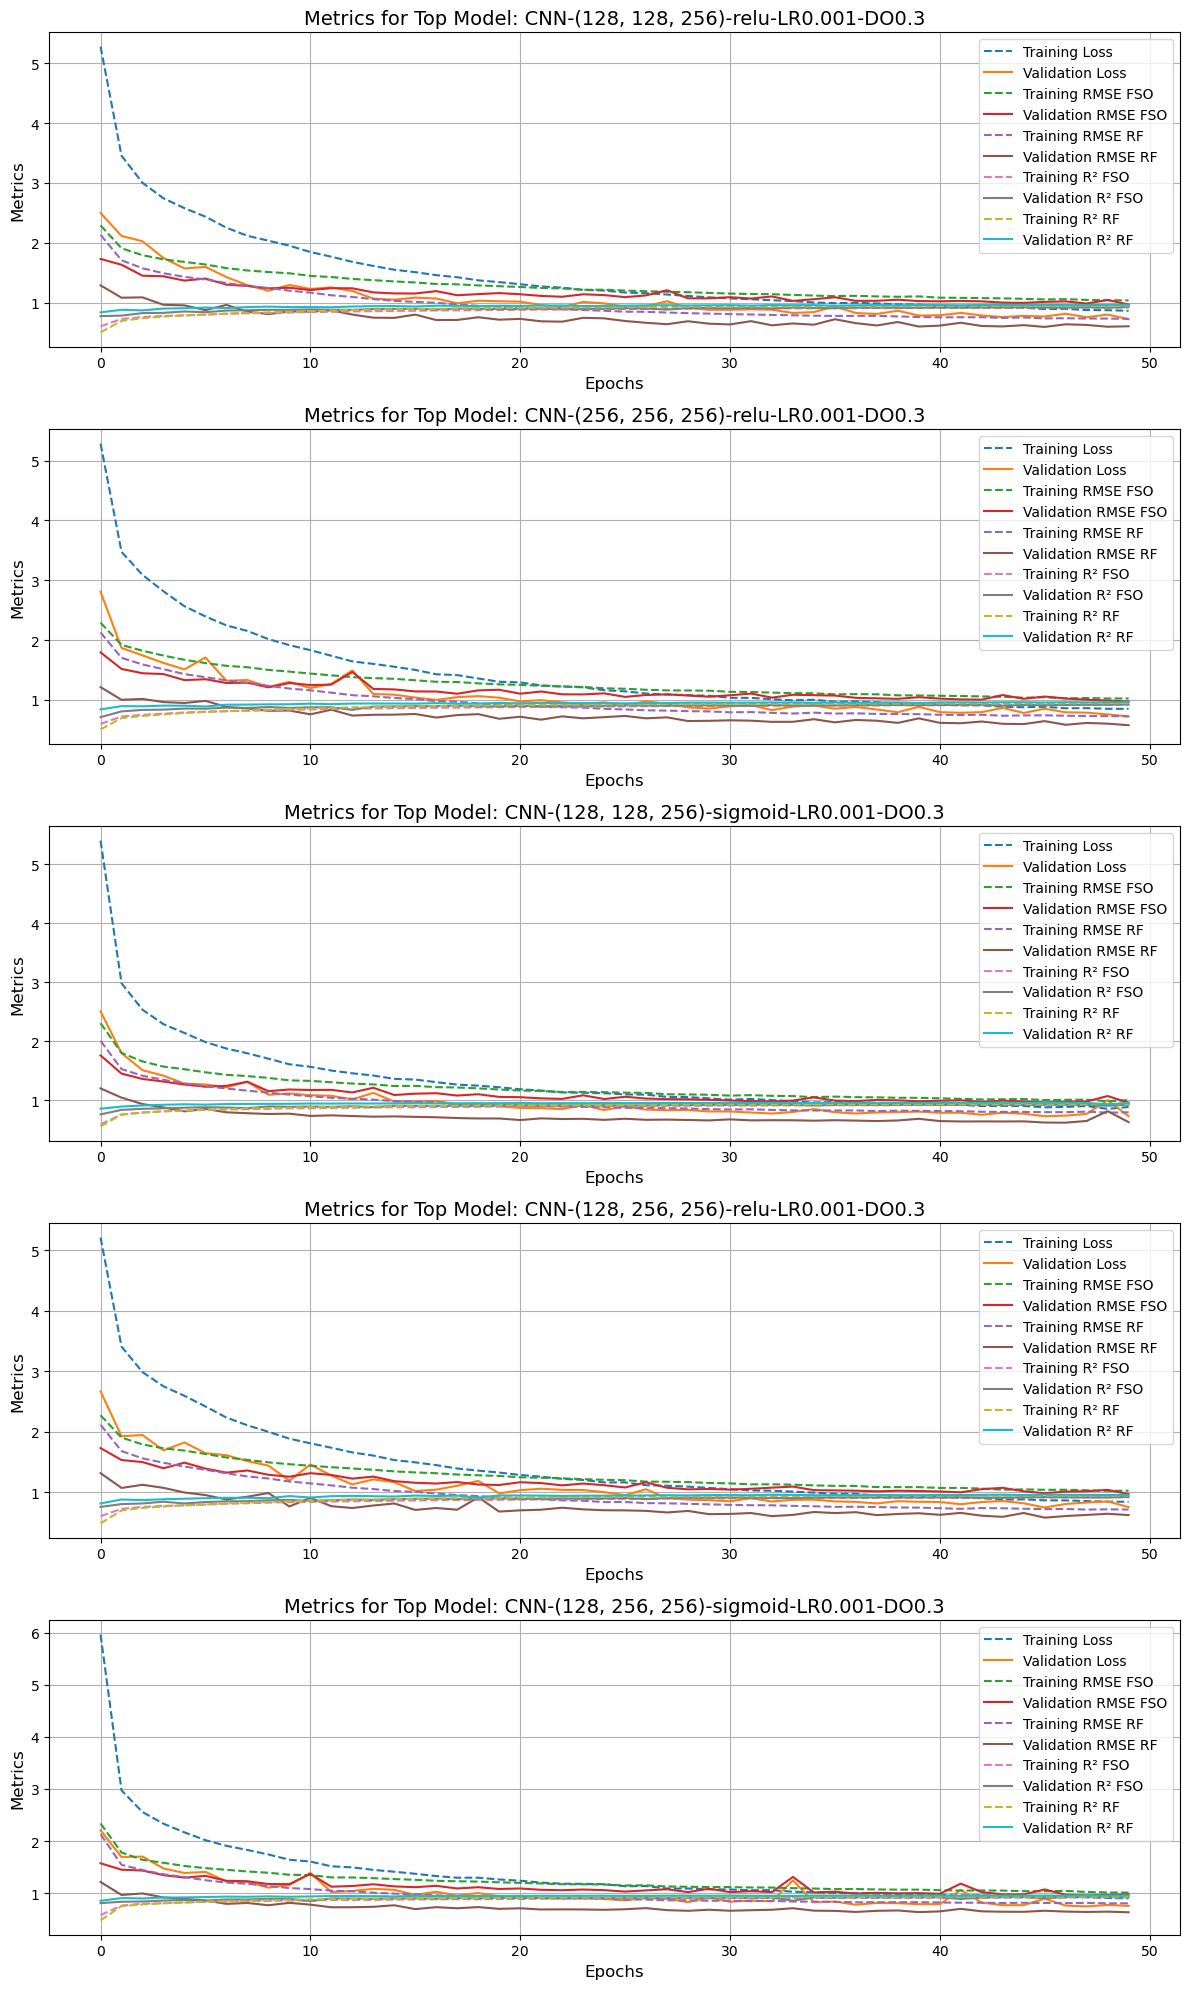

In [17]:
# Plot metrics for the top 5 models
plot_best_models(cnn_multi_results, cnn_multi_histories, top_num=5)

In [19]:
# Save the best ANN model for FSO attenuation
save_best_model(cnn_multi_results, cnn_multi_models, cnn_multi_histories, "CNN")


Best CNN model saved to: saved_models/multioutput_best_CNN_model.h5

Best CNN Model Details:
Model Name                  CNN-(128, 128, 256)-relu-LR0.001-DO0.3
Filters                                            (128, 128, 256)
Conv Layers                                                      3
Activation                                                    relu
Learning Rate                                                0.001
Dropout Rate                                                   0.3
Train RMSE FSO                                            1.035512
Val RMSE FSO                                              0.966935
Train RMSE RF                                             0.727244
Val RMSE RF                                               0.603431
Train R² FSO                                              0.917938
Val R² FSO                                                0.925631
Train R² RF                                               0.944924
Val R² RF                          

'saved_models/multioutput_best_CNN_model.h5'

In [20]:
def load_and_predict(model_path, X_val, output_path, df_prediction):
    """
    Load a trained model, make predictions, and save the updated results.

    Parameters:
    - model_path (str): Path to the saved model file.
    - X_val (DataFrame): Validation feature dataset.
    - output_path (str): Path to save the updated results.
    - df_method1 (DataFrame): Original DataFrame to update with predictions.
    - label (str): Label for the predictions (default is "FSO").

    Returns:
    - None
    """
    # Load the model
    model = load_model(model_path,compile=False)
    print(f"Model loaded from {model_path}")

    # Make predictions
    predicted_values = model.predict(X_val).squeeze()
    print(f"Predictions completed")

    # Assign each column to its respective label
    df_prediction['Predicted_FSO'] = predicted_values[:, 0]  # First column: FSO
    df_prediction['Predicted_RF'] = predicted_values[:, 1]   # Second column: RF

    # Save the updated DataFrame
    df_prediction.to_csv(output_path, index=False)
    print(f"Updated results saved to: {output_path}")

In [21]:
# === Configuration ===
model_path = 'saved_models/multioutput_best_CNN_model.h5'
df_prediction = pd.read_csv("Data/Splitting/Validation/Generic/X/X_val.csv")
output_path = 'Data/Predicted/Validation/val_cnn_combined_prediction.csv'  # Final output

load_and_predict(
    model_path=model_path,
    X_val=X_val,
    output_path=output_path,
    df_prediction=df_prediction
)

Model loaded from saved_models/multioutput_best_CNN_model.h5
457/457 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predictions completed
Updated results saved to: Data/Predicted/Validation/val_cnn_combined_prediction.csv
